# Task 2 – Preparación de Datos
## Detección de Sitios Web Maliciosos (Phishing)

Dataset: Web Page Phishing Detection Dataset

In [20]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

## 1. Carga y Limpieza de Datos

In [21]:
# Cargar el dataset
df = pd.read_csv('dataset_phishing.csv')

# Información básica del dataset
print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas del dataset ({len(df.columns)}):")
print(df.columns.tolist())
print("\n")
df.info()

INFORMACIÓN GENERAL DEL DATASET
Dimensiones: 11430 filas x 89 columnas

Columnas del dataset (89):
['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_h

In [22]:
# Exploración inicial de los datos
print("=" * 60)
print("PRIMERAS FILAS DEL DATASET")
print("=" * 60)
df.head()

PRIMERAS FILAS DEL DATASET


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,nb_underscore,nb_tilde,nb_percent,nb_slash,nb_star,nb_colon,nb_comma,nb_semicolumn,nb_dollar,nb_space,nb_www,nb_com,nb_dslash,http_in_path,https_token,ratio_digits_url,ratio_digits_host,punycode,port,tld_in_path,tld_in_subdomain,abnormal_subdomain,nb_subdomains,prefix_suffix,random_domain,shortening_service,path_extension,nb_redirection,nb_external_redirection,length_words_raw,char_repeat,shortest_words_raw,shortest_word_host,shortest_word_path,longest_words_raw,longest_word_host,longest_word_path,avg_words_raw,avg_word_host,avg_word_path,phish_hints,domain_in_brand,brand_in_subdomain,brand_in_path,suspecious_tld,statistical_report,nb_hyperlinks,ratio_intHyperlinks,ratio_extHyperlinks,ratio_nullHyperlinks,nb_extCSS,ratio_intRedirection,ratio_extRedirection,ratio_intErrors,ratio_extErrors,login_form,external_favicon,links_in_tags,submit_email,ratio_intMedia,ratio_extMedia,sfh,iframe,popup_window,safe_anchor,onmouseover,right_clic,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,0,0,0,0,3,0,1,0,0,0,0,1,0,0,0,1,0.000000,0.0,0,0,0,0,0,3,0,0,0,0,0,0,4,4,3,3,3,11,11,6,5.750000,7.0,4.500000,0,0,0,0,0,0,17,0.529412,0.470588,0,0,0,0.875000,0,0.500000,0,0,80.000000,0,100.000000,0.000000,0,0,0,0.0,0,0,0,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,0,0,0,0,1,0.220779,0.0,0,0,0,0,0,1,0,0,0,0,1,0,4,4,2,19,2,32,19,32,15.750000,19.0,14.666667,0,0,0,0,0,0,30,0.966667,0.033333,0,0,0,0.000000,0,0.000000,0,0,100.000000,0,80.000000,20.000000,0,0,0,100.0,0,0,0,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,3,2,0,0,5,0,1,0,0,0,0,0,1,0,0,0,0.150794,0.0,0,0,0,1,0,3,1,0,0,0,1,0,12,2,2,3,2,17,13,17,8.250000,8.4,8.142857,0,0,0,0,0,0,4,1.000000,0.000000,0,0,0,0.000000,0,0.000000,0,0,100.000000,0,0.000000,0.000000,0,0,0,100.0,0,0,0,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,1,0.000000,0.0,0,0,0,0,0,2,0,0,0,0,1,0,1,0,5,5,0,5,5,0,5.000000,5.0,0.000000,0,0,0,0,0,0,149,0.973154,0.026846,0,0,0,0.250000,0,0.250000,0,0,100.000000,0,96.428571,3.571429,0,0,0,62.5,0,0,0,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,1,0,0,0,1,0.000000,0.0,0,0,0,0,0,2,0,0,0,0,1,0,6,3,3,3,4,11,7,11,6.333333,5.0,7.000000,0,0,0,0,0,0,102,0.470588,0.529412,0,0,0,0.537037,0,0.018519,1,0,76.470588,0,0.000000,100.000000,0,0,0,0.0,0,0,0,0,1,0,224,8175,8725,0,0,6,legitimate


In [23]:
# Verificar valores nulos y estadísticas descriptivas
print("=" * 60)
print("VALORES NULOS POR COLUMNA")
print("=" * 60)
null_counts = df.isnull().sum()
print(f"Total de valores nulos: {null_counts.sum()}")
if null_counts.sum() > 0:
    print(null_counts[null_counts > 0])
else:
    print("No hay valores nulos en el dataset ✓")

print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (status)")
print("=" * 60)
print(df['status'].value_counts())
print(f"\nPorcentaje de phishing: {(df['status'] == 'phishing').mean() * 100:.2f}%")
print(f"Porcentaje de legitimate: {(df['status'] == 'legitimate').mean() * 100:.2f}%")

VALORES NULOS POR COLUMNA
Total de valores nulos: 0
No hay valores nulos en el dataset ✓

DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (status)
status
legitimate    5715
phishing      5715
Name: count, dtype: int64

Porcentaje de phishing: 50.00%
Porcentaje de legitimate: 50.00%


In [24]:
# Eliminar columnas irrelevantes
# 'url' es un identificador único y no aporta información numérica útil para el modelo
columns_to_drop = ['url']

print("=" * 60)
print("ELIMINACIÓN DE COLUMNAS IRRELEVANTES")
print("=" * 60)
print(f"Columnas a eliminar: {columns_to_drop}")
print(f"Razón: 'url' es un identificador único que no aporta información predictiva")

df_clean = df.drop(columns=columns_to_drop)
print(f"\nDimensiones después de limpieza: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")

ELIMINACIÓN DE COLUMNAS IRRELEVANTES
Columnas a eliminar: ['url']
Razón: 'url' es un identificador único que no aporta información predictiva

Dimensiones después de limpieza: 11430 filas x 88 columnas


## 2. Codificación de Variables Categóricas

In [25]:
# Identificar variables categóricas
print("=" * 60)
print("TIPOS DE DATOS EN EL DATASET")
print("=" * 60)
print(df_clean.dtypes.value_counts())

# Identificar columnas no numéricas
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"\nColumnas categóricas encontradas: {categorical_cols}")

# Codificar la variable objetivo 'status'
# phishing = 1, legitimate = 0
le = LabelEncoder()
df_clean['status_encoded'] = le.fit_transform(df_clean['status'])

print("\n" + "=" * 60)
print("CODIFICACIÓN DE LA VARIABLE OBJETIVO")
print("=" * 60)
print(f"Mapeo: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"  - legitimate → 0")
print(f"  - phishing → 1")

# Verificar la codificación
print(f"\nDistribución después de codificación:")
print(df_clean['status_encoded'].value_counts())

TIPOS DE DATOS EN EL DATASET
int64      74
float64    13
object      1
Name: count, dtype: int64

Columnas categóricas encontradas: ['status']

CODIFICACIÓN DE LA VARIABLE OBJETIVO
Mapeo: {'legitimate': np.int64(0), 'phishing': np.int64(1)}
  - legitimate → 0
  - phishing → 1

Distribución después de codificación:
status_encoded
0    5715
1    5715
Name: count, dtype: int64


## 3. Selección de Features (Análisis de Correlación)

TOP 20 FEATURES CON MAYOR CORRELACIÓN CON 'status'
google_index           0.731171
page_rank              0.511137
nb_www                 0.443468
ratio_digits_url       0.356395
domain_in_title        0.342807
nb_hyperlinks          0.342628
phish_hints            0.335393
domain_age             0.331889
ip                     0.321698
nb_qm                  0.294319
length_url             0.248580
ratio_intHyperlinks    0.243982
nb_slash               0.242270
length_hostname        0.238322
nb_eq                  0.233386
ratio_digits_host      0.224335
shortest_word_host     0.223084
prefix_suffix          0.214681
longest_word_path      0.212709
tld_in_subdomain       0.208884
Name: status_encoded, dtype: float64


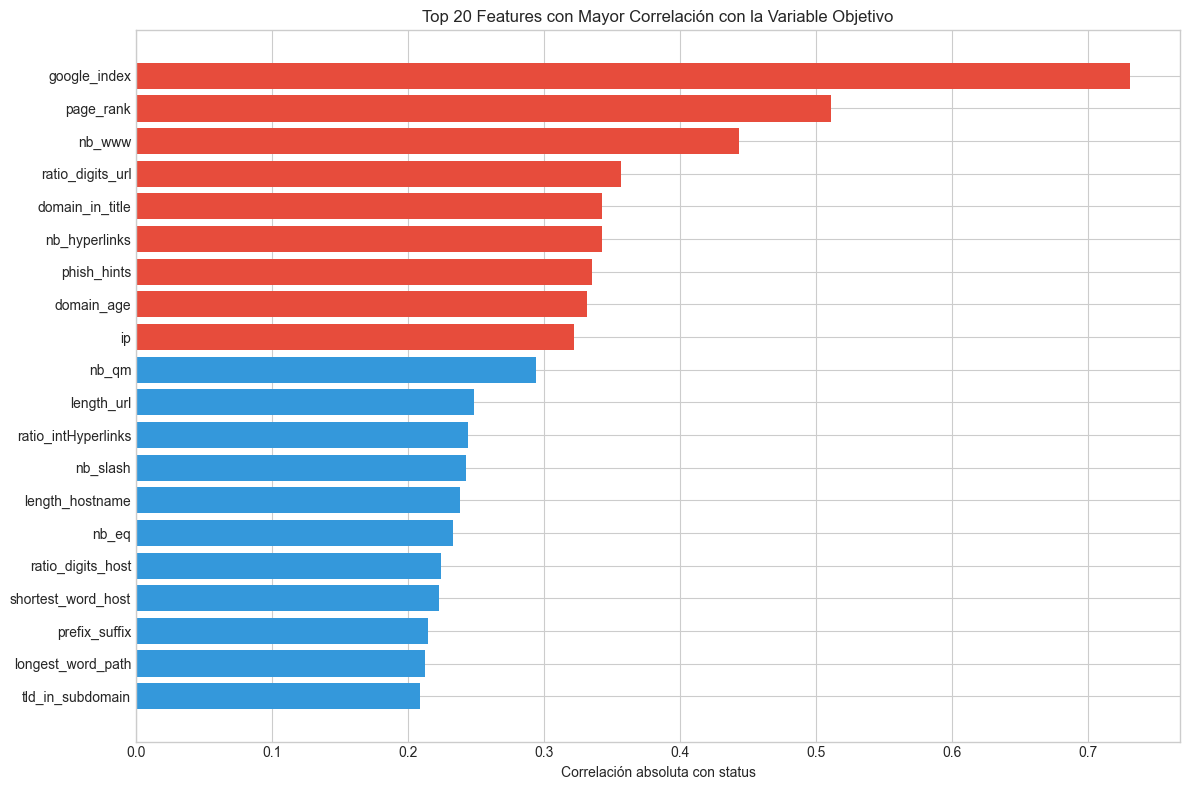

In [26]:
# Preparar datos para análisis de correlación
# Seleccionar solo columnas numéricas (excluyendo 'status' original)
df_numeric = df_clean.drop(columns=['status']).select_dtypes(include=[np.number])

# Calcular correlación con la variable objetivo
correlations = df_numeric.corr()['status_encoded'].drop('status_encoded').abs().sort_values(ascending=False)

print("=" * 60)
print("TOP 20 FEATURES CON MAYOR CORRELACIÓN CON 'status'")
print("=" * 60)
print(correlations.head(20))

# Visualizar las correlaciones más importantes
plt.figure(figsize=(12, 8))
top_20_features = correlations.head(20)
colors = ['#e74c3c' if x > 0.3 else '#3498db' for x in top_20_features.values]
bars = plt.barh(range(len(top_20_features)), top_20_features.values, color=colors)
plt.yticks(range(len(top_20_features)), top_20_features.index)
plt.xlabel('Correlación absoluta con status')
plt.title('Top 20 Features con Mayor Correlación con la Variable Objetivo')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
# Seleccionar las 2 variables con mayor correlación para visualización 2D
top_2_features = correlations.head(2).index.tolist()

print("=" * 60)
print("FEATURES SELECCIONADAS PARA VISUALIZACIÓN 2D")
print("=" * 60)
print(f"Feature 1: {top_2_features[0]} (correlación: {correlations[top_2_features[0]]:.4f})")
print(f"Feature 2: {top_2_features[1]} (correlación: {correlations[top_2_features[1]]:.4f})")

# Crear DataFrame con las features seleccionadas
X = df_clean[top_2_features].copy()
y = df_clean['status_encoded'].copy()

print(f"\nDimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

FEATURES SELECCIONADAS PARA VISUALIZACIÓN 2D
Feature 1: google_index (correlación: 0.7312)
Feature 2: page_rank (correlación: 0.5111)

Dimensiones de X: (11430, 2)
Dimensiones de y: (11430,)


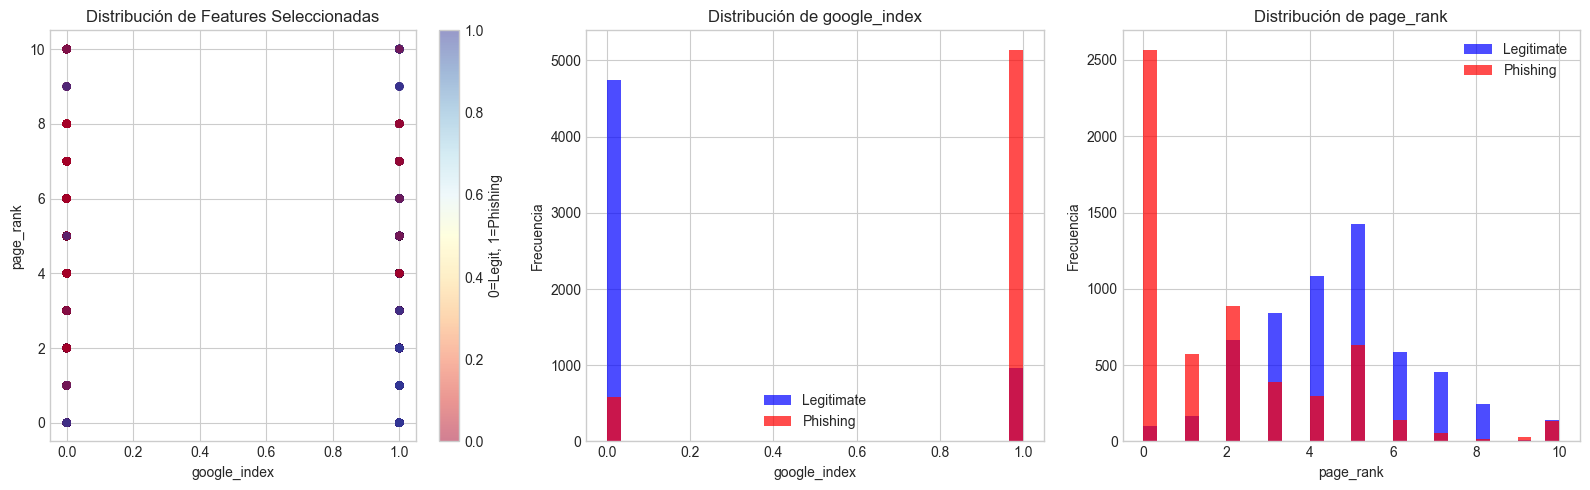

In [28]:
# Visualizar la distribución de las 2 features seleccionadas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter plot de las 2 features
scatter = axes[0].scatter(X[top_2_features[0]], X[top_2_features[1]], 
                          c=y, cmap='RdYlBu', alpha=0.5, edgecolors='none')
axes[0].set_xlabel(top_2_features[0])
axes[0].set_ylabel(top_2_features[1])
axes[0].set_title('Distribución de Features Seleccionadas')
plt.colorbar(scatter, ax=axes[0], label='0=Legit, 1=Phishing')

# Histogramas de cada feature
for idx, feature in enumerate(top_2_features):
    ax = axes[idx + 1]
    df_clean[df_clean['status'] == 'legitimate'][feature].hist(
        ax=ax, alpha=0.7, label='Legitimate', bins=30, color='blue')
    df_clean[df_clean['status'] == 'phishing'][feature].hist(
        ax=ax, alpha=0.7, label='Phishing', bins=30, color='red')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Distribución de {feature}')
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Escalado de Datos (Normalización)

El escalado es **obligatorio** porque:
- **Descenso del gradiente**: Converge muy lentamente sin escalado debido a gradientes desbalanceados
- **KNN**: Las distancias se distorsionan si una dimensión tiene magnitudes mucho mayores que otra

In [29]:
# Estadísticas antes del escalado
print("=" * 60)
print("ESTADÍSTICAS ANTES DEL ESCALADO")
print("=" * 60)
print(X.describe())

# Verificar la escala de las variables
print(f"\nRango de {top_2_features[0]}: [{X[top_2_features[0]].min():.2f}, {X[top_2_features[0]].max():.2f}]")
print(f"Rango de {top_2_features[1]}: [{X[top_2_features[1]].min():.2f}, {X[top_2_features[1]].max():.2f}]")

ESTADÍSTICAS ANTES DEL ESCALADO
       google_index     page_rank
count  11430.000000  11430.000000
mean       0.533946      3.185739
std        0.498868      2.536955
min        0.000000      0.000000
25%        0.000000      1.000000
50%        1.000000      3.000000
75%        1.000000      5.000000
max        1.000000     10.000000

Rango de google_index: [0.00, 1.00]
Rango de page_rank: [0.00, 10.00]


In [30]:
# Aplicar StandardScaler (z-score normalization)
# StandardScaler: transforma los datos para tener media=0 y desviación estándar=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir a DataFrame para mejor visualización
X_scaled_df = pd.DataFrame(X_scaled, columns=top_2_features)

print("=" * 60)
print("ESTADÍSTICAS DESPUÉS DEL ESCALADO (StandardScaler)")
print("=" * 60)
print(X_scaled_df.describe())

print(f"\nRango de {top_2_features[0]}: [{X_scaled_df[top_2_features[0]].min():.2f}, {X_scaled_df[top_2_features[0]].max():.2f}]")
print(f"Rango de {top_2_features[1]}: [{X_scaled_df[top_2_features[1]].min():.2f}, {X_scaled_df[top_2_features[1]].max():.2f}]")

ESTADÍSTICAS DESPUÉS DEL ESCALADO (StandardScaler)
       google_index     page_rank
count  1.143000e+04  1.143000e+04
mean  -9.138214e-17 -8.703061e-18
std    1.000044e+00  1.000044e+00
min   -1.070361e+00 -1.255788e+00
25%   -1.070361e+00 -8.615977e-01
50%    9.342641e-01 -7.321666e-02
75%    9.342641e-01  7.151644e-01
max    9.342641e-01  2.686117e+00

Rango de google_index: [-1.07, 0.93]
Rango de page_rank: [-1.26, 2.69]


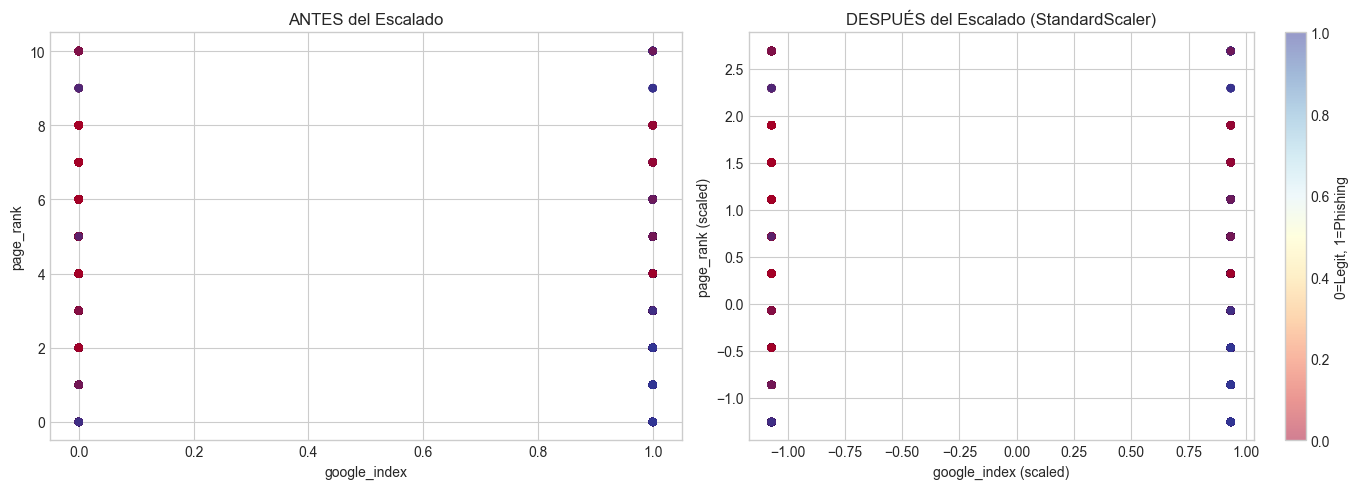

In [31]:
# Visualizar comparación antes y después del escalado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes del escalado
axes[0].scatter(X[top_2_features[0]], X[top_2_features[1]], 
                c=y, cmap='RdYlBu', alpha=0.5, edgecolors='none')
axes[0].set_xlabel(top_2_features[0])
axes[0].set_ylabel(top_2_features[1])
axes[0].set_title('ANTES del Escalado')

# Después del escalado
scatter = axes[1].scatter(X_scaled_df[top_2_features[0]], X_scaled_df[top_2_features[1]], 
                          c=y, cmap='RdYlBu', alpha=0.5, edgecolors='none')
axes[1].set_xlabel(f'{top_2_features[0]} (scaled)')
axes[1].set_ylabel(f'{top_2_features[1]} (scaled)')
axes[1].set_title('DESPUÉS del Escalado (StandardScaler)')
plt.colorbar(scatter, ax=axes[1], label='0=Legit, 1=Phishing')

plt.tight_layout()
plt.show()

## 5. División de Datos (Train/Test Split)

In [32]:
# Dividir los datos: 80% entrenamiento, 20% prueba
# Usamos stratify para mantener la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,  # Usamos los datos escalados
    y, 
    test_size=0.20, 
    random_state=42,  # Para reproducibilidad
    stratify=y  # Mantener proporción de clases
)

print("=" * 60)
print("DIVISIÓN DE DATOS (80% Train / 20% Test)")
print("=" * 60)
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras ({X_test.shape[0]/len(y)*100:.1f}%)")

print(f"\nDistribución de clases en entrenamiento:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Legitimate' if u == 0 else 'Phishing'
    print(f"  {label}: {c} ({c/len(y_train)*100:.1f}%)")

print(f"\nDistribución de clases en prueba:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Legitimate' if u == 0 else 'Phishing'
    print(f"  {label}: {c} ({c/len(y_test)*100:.1f}%)")

DIVISIÓN DE DATOS (80% Train / 20% Test)
Tamaño del conjunto de entrenamiento: 9144 muestras (80.0%)
Tamaño del conjunto de prueba: 2286 muestras (20.0%)

Distribución de clases en entrenamiento:
  Legitimate: 4572 (50.0%)
  Phishing: 4572 (50.0%)

Distribución de clases en prueba:
  Legitimate: 1143 (50.0%)
  Phishing: 1143 (50.0%)


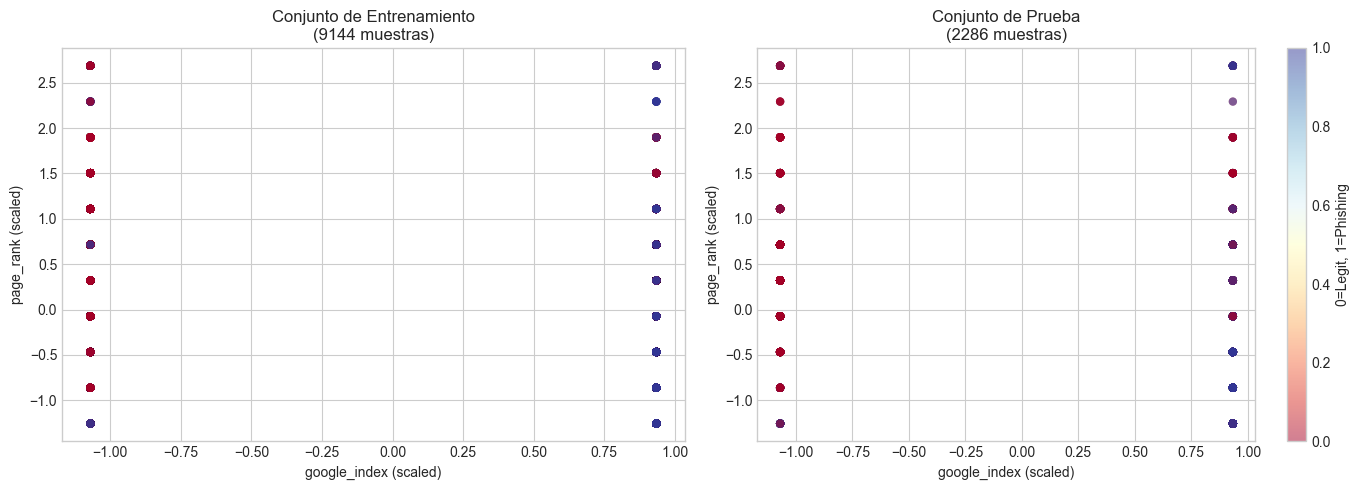

In [33]:
# Visualizar la división de datos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu', alpha=0.5, edgecolors='none')
axes[0].set_xlabel(f'{top_2_features[0]} (scaled)')
axes[0].set_ylabel(f'{top_2_features[1]} (scaled)')
axes[0].set_title(f'Conjunto de Entrenamiento\n({X_train.shape[0]} muestras)')

# Test set
scatter = axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlBu', alpha=0.5, edgecolors='none')
axes[1].set_xlabel(f'{top_2_features[0]} (scaled)')
axes[1].set_ylabel(f'{top_2_features[1]} (scaled)')
axes[1].set_title(f'Conjunto de Prueba\n({X_test.shape[0]} muestras)')
plt.colorbar(scatter, ax=axes[1], label='0=Legit, 1=Phishing')

plt.tight_layout()
plt.show()

## 6. Resumen de la Preparación de Datos

In [34]:
# Resumen final de la preparación de datos
print("=" * 70)
print("RESUMEN DE LA PREPARACIÓN DE DATOS")
print("=" * 70)

print("\n DATASET ORIGINAL:")
print(f"   - Filas: {df.shape[0]}")
print(f"   - Columnas: {df.shape[1]}")

print("\n LIMPIEZA:")
print(f"   - Columnas eliminadas: ['url'] (identificador único)")
print(f"   - Valores nulos: 0")

print("\n CODIFICACIÓN:")
print(f"   - Variable objetivo: 'status' → 'status_encoded'")
print(f"   - Mapeo: legitimate=0, phishing=1")

print("\n FEATURES SELECCIONADAS (para visualización 2D):")
print(f"   - Feature 1: {top_2_features[0]} (corr: {correlations[top_2_features[0]]:.4f})")
print(f"   - Feature 2: {top_2_features[1]} (corr: {correlations[top_2_features[1]]:.4f})")

print("\n ESCALADO:")
print(f"   - Método: StandardScaler (z-score)")
print(f"   - Media después del escalado: ~0")
print(f"   - Desviación estándar después del escalado: ~1")

print("\n DIVISIÓN DE DATOS:")
print(f"   - Entrenamiento: {X_train.shape[0]} muestras (80%)")
print(f"   - Prueba: {X_test.shape[0]} muestras (20%)")
print(f"   - Estratificación: Sí (mantiene proporción de clases)")

print("\n VARIABLES DISPONIBLES PARA MODELADO:")
print(f"   - X_train: {X_train.shape}")
print(f"   - X_test: {X_test.shape}")
print(f"   - y_train: {y_train.shape}")
print(f"   - y_test: {y_test.shape}")
print(f"   - top_2_features: {top_2_features}")
print(f"   - scaler: StandardScaler (fitted)")
print("=" * 70)

RESUMEN DE LA PREPARACIÓN DE DATOS

 DATASET ORIGINAL:
   - Filas: 11430
   - Columnas: 89

 LIMPIEZA:
   - Columnas eliminadas: ['url'] (identificador único)
   - Valores nulos: 0

 CODIFICACIÓN:
   - Variable objetivo: 'status' → 'status_encoded'
   - Mapeo: legitimate=0, phishing=1

 FEATURES SELECCIONADAS (para visualización 2D):
   - Feature 1: google_index (corr: 0.7312)
   - Feature 2: page_rank (corr: 0.5111)

 ESCALADO:
   - Método: StandardScaler (z-score)
   - Media después del escalado: ~0
   - Desviación estándar después del escalado: ~1

 DIVISIÓN DE DATOS:
   - Entrenamiento: 9144 muestras (80%)
   - Prueba: 2286 muestras (20%)
   - Estratificación: Sí (mantiene proporción de clases)

 VARIABLES DISPONIBLES PARA MODELADO:
   - X_train: (9144, 2)
   - X_test: (2286, 2)
   - y_train: (9144,)
   - y_test: (2286,)
   - top_2_features: ['google_index', 'page_rank']
   - scaler: StandardScaler (fitted)


## TASK 3

Reglas importantes:

• Puede usar numpy, pandas, matplotlib.

• No tiene permitido usar sklearn (fit/predict), tensorflow, pytorch para esta sección.

• Deben implementar las fórmulas matemáticas matriciales.

Regresión Logística con Descenso del Gradiente
Implemente un clasificador binario para detectar Phishing. Para ello, tome en cuenta lo siguiente:
1. Implemente la función sigmoide g(z) y la predicción 𝑦̂ = 𝑔(𝑋 ⋅ 𝑤 + 𝑏) (Hipótesis)
2. Implemente la función de Log Loss (Binary Cross-Entropy) (Costo)
3. Implemente el bucle de Gradient Descent (Entrenamiento):

a. En cada época, actualice los pesos w y el sesgo b.
b. Guarde el historial de pérdida.
c. Debe asegurarse de entregar dentro de su notebook:
    • Gráfica de Costo: Muestre cómo el error baja en cada época. (Si no baja, su learning rate es muy
    alto o su gradiente está mal).
    • Threshold de Decisión: Haga un scatter plot de las 2 variables seleccionadas (puntos
    azules=legítimo, rojos=phishing) y dibuje la línea que aprendió su modelo para separarlos.

In [35]:
def sigmoide(z):
    return 1/(1+np.exp(-z))

def prediccion(x, weight, bias):
    z = np.dot(x, weight) + bias
    return sigmoide(z)

def log_loss(y_true, y_pred):
    m = y_true.shape[0]
    epsilon = 1e-15  # Para evitar log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = - (1/m) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

def gradient_descent(X, y, learning_rate, epochs):
    weight = np.zeros(X.shape[1])
    bias = 0
    historic_loss = []
    
    for epoch in range(epochs):
        y_pred = prediccion(X, weight, bias)
        loss = log_loss(y, y_pred)
        historic_loss.append(loss)
        
        # calculo de gradientes
        m = X.shape[0]
        dw = (1/m) * np.dot(X.T, (y_pred - y)) # esta formula en forma matematica es: 
        db = (1/m) * np.sum(y_pred - y)
        
        weight -= learning_rate * dw
        bias -= learning_rate * db
    return weight, bias, historic_loss



### Gráfico de costo 

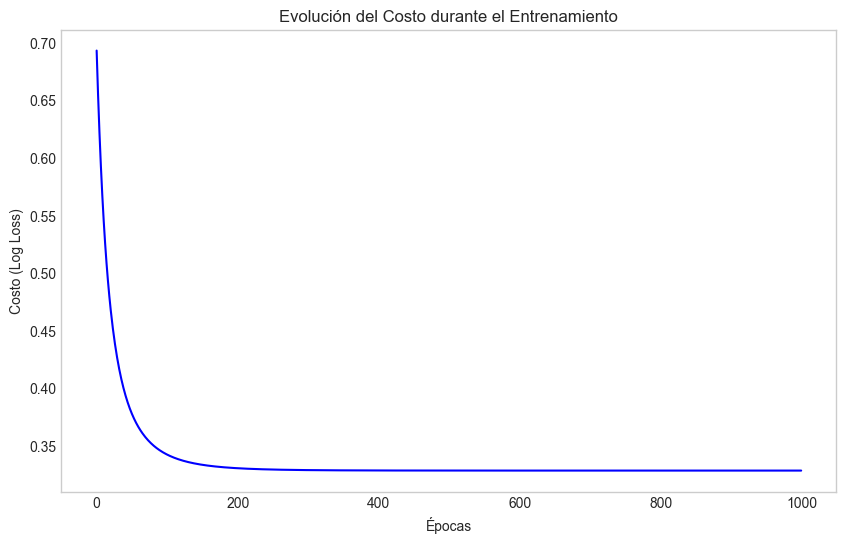

In [37]:
learning_rate = 0.1
epochs = 1000

weight, bias, historic_loss = gradient_descent(X_train, y_train, learning_rate, epochs)


plt.figure(figsize=(10, 6))
plt.plot(range(epochs), historic_loss, color="blue")
plt.xlabel("Épocas")
plt.ylabel("Costo (Log Loss)")
plt.title("Evolución del Costo durante el Entrenamiento")
plt.grid()
plt.show()

### Threshold de Decisión

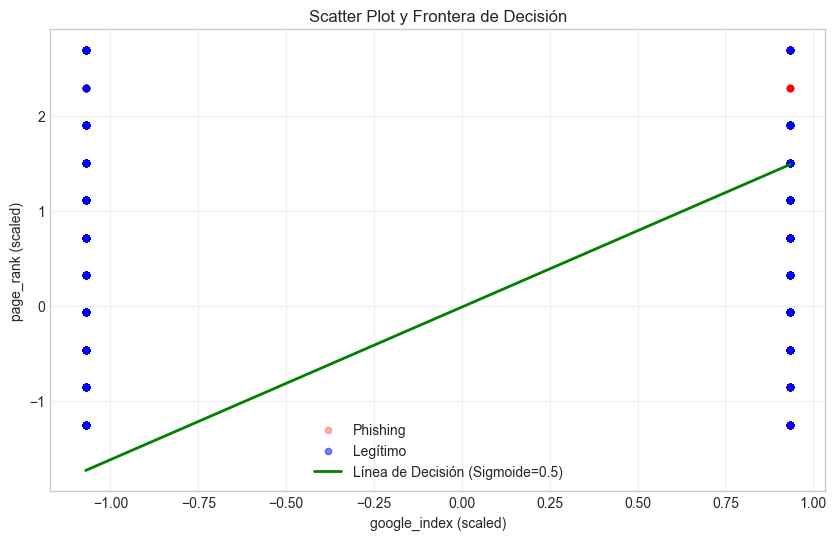

In [42]:
plt.figure(figsize=(10,6))
# Graficar phishing primero (con más transparencia) para que los legítimos sean visibles
plt.scatter(X_train[y_train==1][:, 0], X_train[y_train==1][:, 1], 
            color="red", alpha=0.3, s=20, label="Phishing")
plt.scatter(X_train[y_train==0][:, 0], X_train[y_train==0][:, 1], 
            color="blue", alpha=0.5, s=20, label="Legítimo")

# LÍNEA DE DECISIÓN: W1*x1 + W2*x2 + b = 0 (donde sigmoide = 0.5)
# Para dos variables: x2 = (-w1*x1 - b) / w2

x_vals = np.linspace(X_train[:,0].min(), X_train[:,0].max(), 100)
if weight[1] != 0:
    y_vals = -(weight[0]*x_vals + bias) / weight[1]
    plt.plot(x_vals, y_vals, color="green", linewidth=2, label="Línea de Decisión (Sigmoide=0.5)")
else: 
    plt.axvline(x=-bias/weight[0], color="green", linewidth=2, label="Línea de Decisión (Sigmoide=0.5)")

plt.xlabel(f'{top_2_features[0]} (scaled)')
plt.ylabel(f'{top_2_features[1]} (scaled)')
plt.title("Scatter Plot y Frontera de Decisión")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [47]:
# Verificar distribución de clases en train
print("Distribución en y_train:")
print(f"Legítimos (0): {np.sum(y_train == 0)}")
print(f"Phishing (1): {np.sum(y_train == 1)}")
print(f"Total: {len(y_train)}")

# Verificar rangos de los datos
print(f"\nRangos de X_train:")
print(f"Feature 1 (google_index): [{X_train[:, 0].min():.2f}, {X_train[:, 0].max():.2f}]")
print(f"Feature 2 (page_rank): [{X_train[:, 1].min():.2f}, {X_train[:, 1].max():.2f}]")

Distribución en y_train:
Legítimos (0): 4572
Phishing (1): 4572
Total: 9144

Rangos de X_train:
Feature 1 (google_index): [-1.07, 0.93]
Feature 2 (page_rank): [-1.26, 2.69]


### Evaluación del Modelo

In [48]:
# Evaluar el modelo en el conjunto de entrenamiento
y_pred_train = prediccion(X_train, weight, bias)
y_pred_train_class = (y_pred_train >= 0.5).astype(int)
accuracy_train = np.mean(y_pred_train_class == y_train)

# Evaluar el modelo en el conjunto de prueba
y_pred_test = prediccion(X_test, weight, bias)
y_pred_test_class = (y_pred_test >= 0.5).astype(int)
accuracy_test = np.mean(y_pred_test_class == y_test)

print("=" * 60)
print("EVALUACIÓN DEL MODELO")
print("=" * 60)
print(f"Accuracy en entrenamiento: {accuracy_train*100:.2f}%")
print(f"Accuracy en prueba: {accuracy_test*100:.2f}%")
print(f"\nCosto final (Log Loss): {historic_loss[-1]:.4f}")
print(f"Pesos aprendidos (w): {weight}")
print(f"Sesgo aprendido (b): {bias:.4f}")

EVALUACIÓN DEL MODELO
Accuracy en entrenamiento: 86.94%
Accuracy en prueba: 85.21%

Costo final (Log Loss): 0.3282
Pesos aprendidos (w): [ 1.82009617 -1.13237778]
Sesgo aprendido (b): -0.0182
